# Tuning report — interactive plots

Single-animal, single-session place-and-reward cell tuning diagnostics. The selection cell in section 2 is the only thing to edit when switching datasets, animals, sessions, or trial types; everything downstream — load and the per-session outputs — works against whatever the selection cell defined. Section 4 cells are thin caller stubs over `sollertia_forgery.analysis.tuning.plotting`; edit the helpers in the package and re-run the affected cell to refresh.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running the section 4 cells picks up plotting helper changes without reloading.

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import cmocean
from ataraxis_base_utilities import LogLevel, console

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    TuningReport,
    plot_per_day_sorted_rate_maps,
    plot_per_trial_activity,
    plot_place_cell_heatmap,
    plot_population_activity_by_position,
    plot_rate_map_heatmap,
    plot_reward_com_histogram,
    plot_speed_and_activity_by_position,
)

## 2. Selection

The only cell to edit when switching datasets, animals, sessions, or trial types. `DATASET_PATH` is the dataset root, `ANIMAL` is a single animal id, `SESSION_INDEX` is a 0-based index into the animal's chronologically sorted session list, and `TRIAL_TYPE` selects which trial type the per-session plots evaluate (set to `None` to fall back to the first trial type in the report).

In [3]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMAL: str = "11"
SESSION_INDEX: int = 0
TRIAL_TYPE: str | None = None

## 3. Load

Reads the dataset, picks the configured animal and session, loads the persisted `TuningReport`, and resolves the active trial type. The per-session plots in section 4 read these objects directly.

In [4]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
dataset_animal = dataset.get_animal(animal=ANIMAL)
sessions = tuple(
    sorted(
        dataset.get_sessions_for_animal(animal=ANIMAL),
        key=lambda dataset_session: dataset_session.session,
    )
)
session = sessions[SESSION_INDEX]
tuning_report = TuningReport.load(session=session)
trial_type: str = (
    TRIAL_TYPE if TRIAL_TYPE is not None else tuning_report.summary.trial_types[0]
)

console.echo(message=f"Dataset: {dataset.name} ({DATASET_PATH})", level=LogLevel.INFO)
console.echo(
    message=(
        f"Animal {ANIMAL}, session [{SESSION_INDEX}] {session.session} "
        f"({len(sessions)} sessions available); trial type {trial_type!r}"
    ),
    level=LogLevel.INFO,
)

2026-05-02 19:59:53.600 | INFO     | Dataset: void (/home/data/Data/void)
2026-05-02 19:59:53.600 | INFO     | Animal 11, session [0] 2025-07-21-15-47-38-718925 (20 sessions available); trial
                                     type 'cyclic_4_cue'


## 4. Per-session outputs

Each cell below calls one helper from `sollertia_forgery.analysis.tuning.plotting` against `tuning_report` and `trial_type`. Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Text summary

In [45]:
console.echo(
    message=f"Animal {ANIMAL} session [{SESSION_INDEX}] tuning summary",
    level=LogLevel.INFO,
)
console.echo(message=tuning_report.summarize(), raw=True)

2026-05-02 18:27:06.709 | INFO     | Animal 11 session [0] tuning summary
Tuning report
Cells: 8179
Trial types: cyclic_4_cue
Sampling rate: 10.00 Hz

Trial type: cyclic_4_cue
------------------------
  Track length:      240.0 cm
  Reward position:   225.0 cm
  Bin size:          5.0 cm (48 bins)
  Place-only:            2377 (29.1%)
  Reliable (lap cov.):   2653 (32.4%)
  Stable (split-half):   4510 (55.1%)
  Peak-significant:      5876 (71.8%)
  Strict place cells:    2039 (24.9%)
  Spatially significant: 7532 (92.1%)
  Reward cells:          906 (11.1%)
  Reward-predictive:     49 (0.6%)
  Reward mixture: weight 0.043, center 189.1 cm (SD 14.2 cm)
  Track-start wt: 0.000 (SD 15.1 cm)
  Track-end wt:   0.000 (SD 11.6 cm)


### 4.2 Place-cell rate-map heatmap

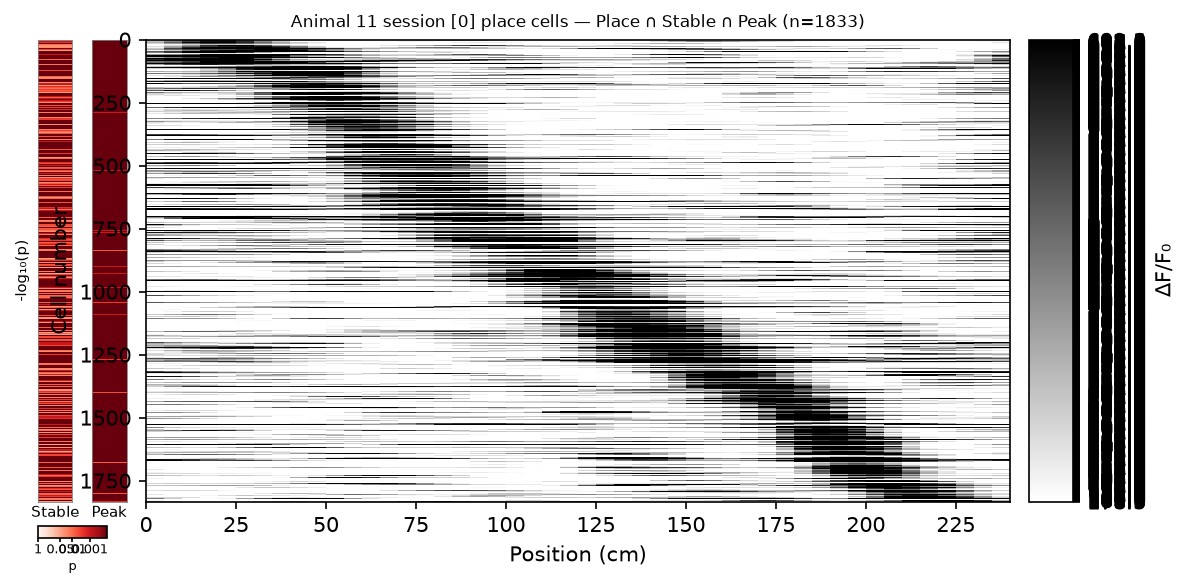

In [46]:
plot_place_cell_heatmap(
    report=tuning_report,
    trial_type=trial_type,
    title=f"Animal {ANIMAL} session [{SESSION_INDEX}] place cells",
)
plt.show()

### 4.3 Reward-cell vs place-cell rate maps

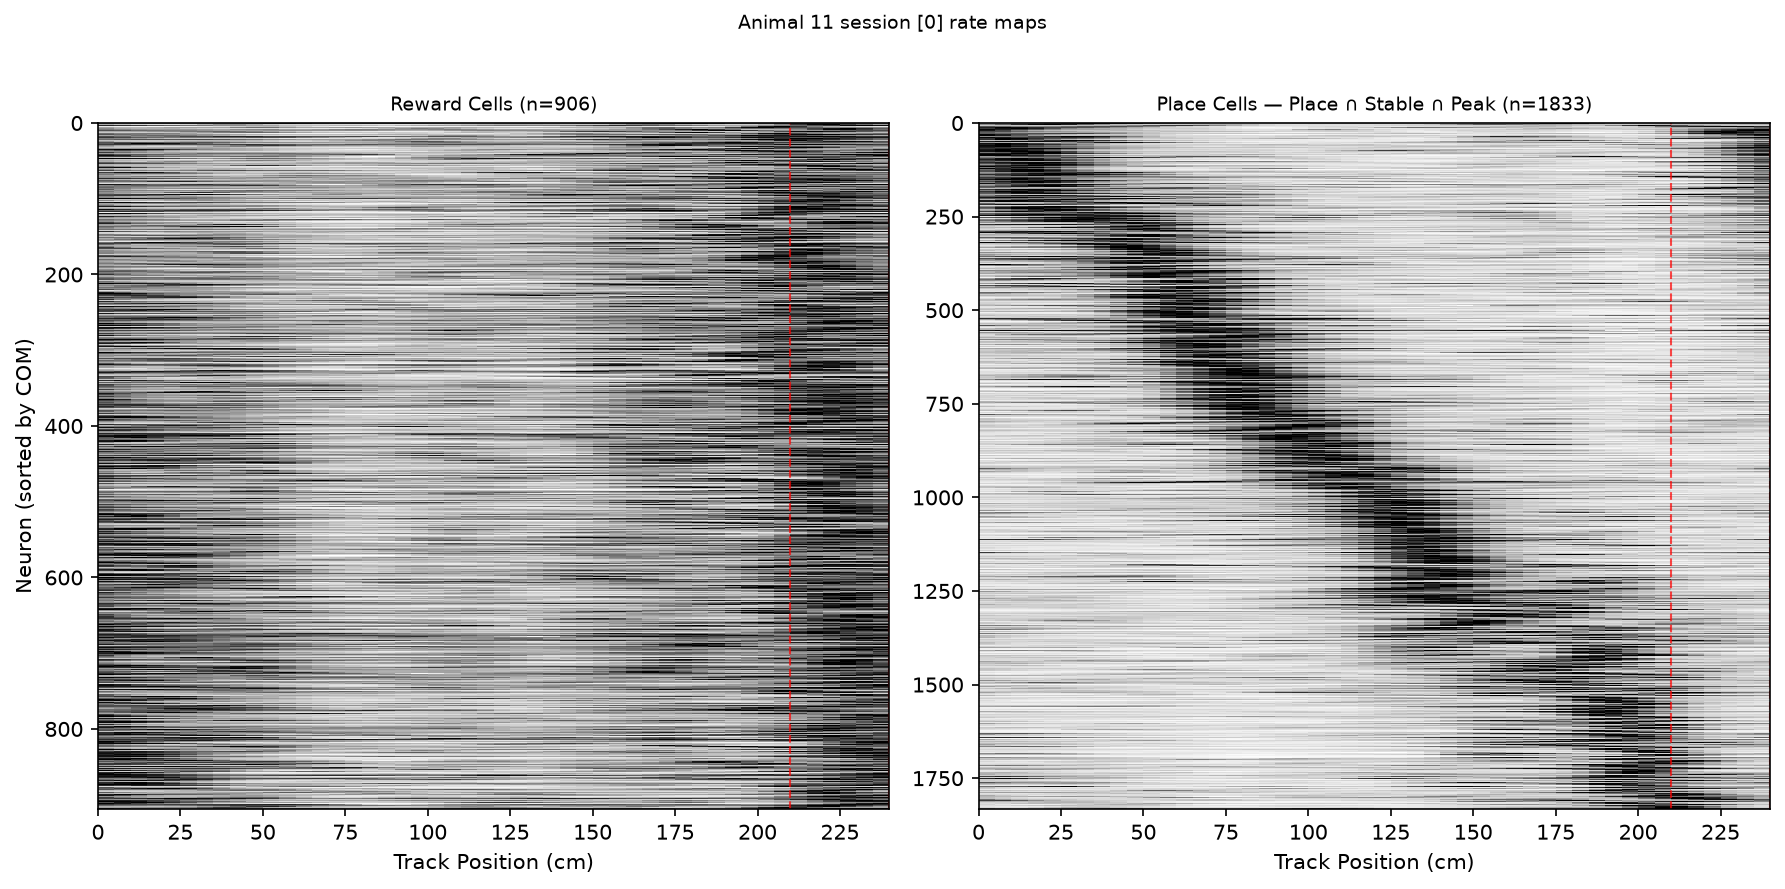

In [47]:
plot_rate_map_heatmap(
    report=tuning_report,
    trial_type=trial_type,
    title=f"Animal {ANIMAL} session [{SESSION_INDEX}] rate maps",
)
plt.show()

### 4.4 Reward-cell COM histogram with mixture fit

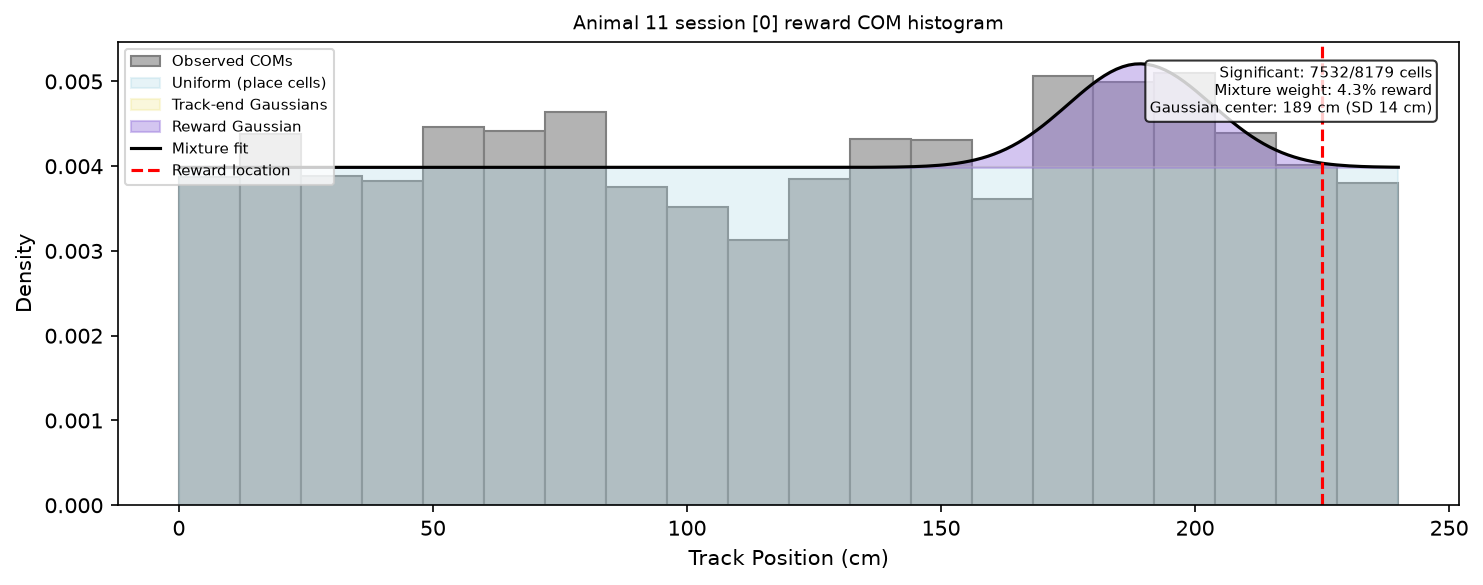

In [48]:
plot_reward_com_histogram(
    report=tuning_report,
    trial_type=trial_type,
    title=f"Animal {ANIMAL} session [{SESSION_INDEX}] reward COM histogram",
)
plt.show()

### 4.5 Population activity by position

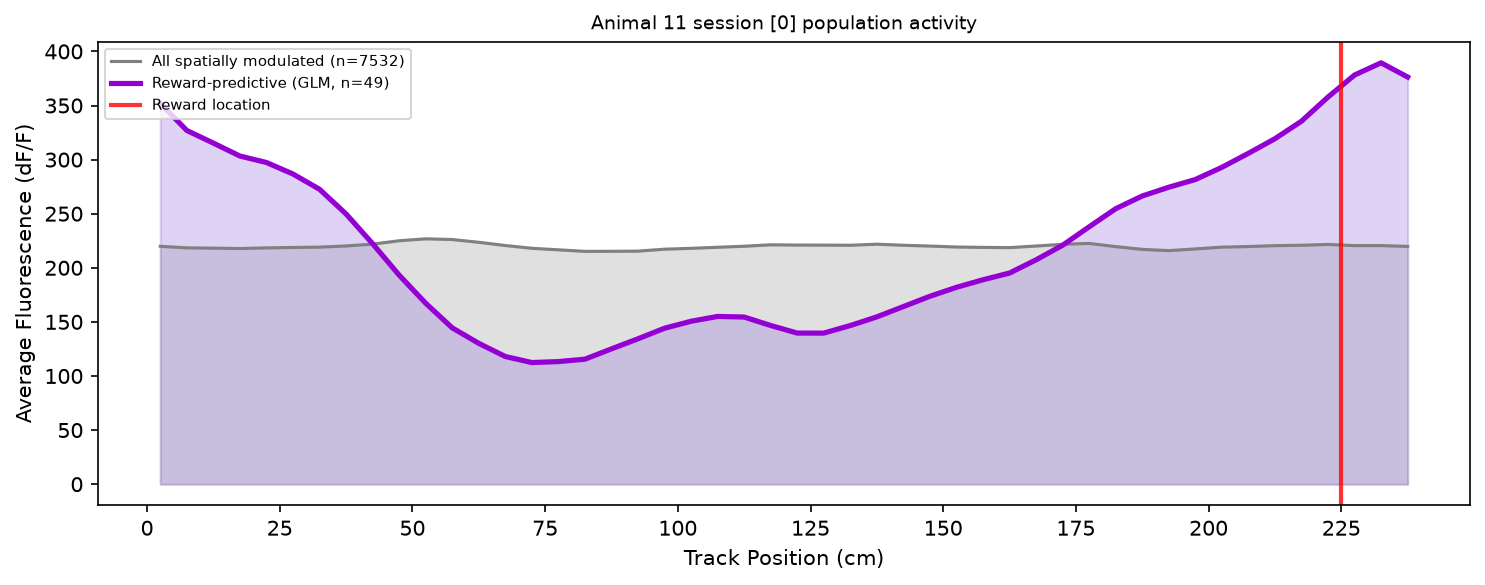

In [49]:
plot_population_activity_by_position(
    report=tuning_report,
    trial_type=trial_type,
    title=f"Animal {ANIMAL} session [{SESSION_INDEX}] population activity",
)
plt.show()

### 4.6 Speed and reward-predictive activity by position

Reads `data.feather` for the session to bin running speed alongside the reward-predictive cell activity.

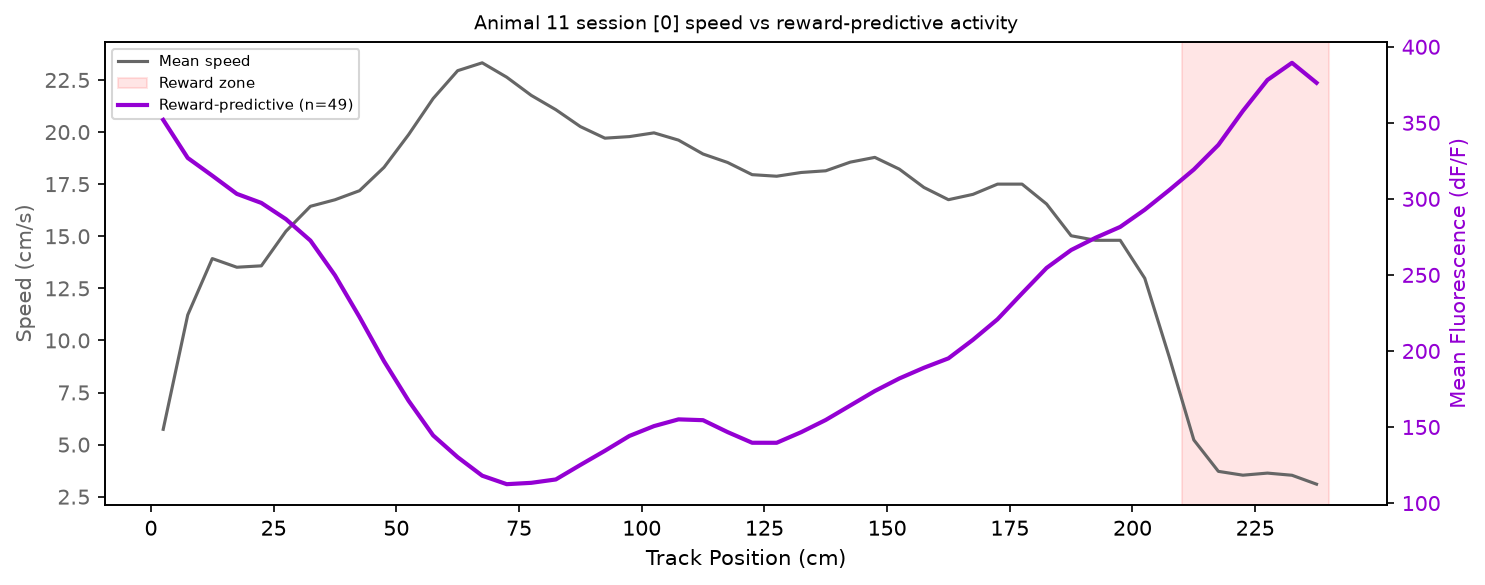

In [50]:
plot_speed_and_activity_by_position(
    report=tuning_report,
    trial_type=trial_type,
    session=session,
    title=f"Animal {ANIMAL} session [{SESSION_INDEX}] speed vs reward-predictive activity",
)
plt.show()

### 4.7 Per-trial activity for example reward-predictive and place cells

Reads `data.feather` for the session to render per-trial activity heatmaps with slowing-onset markers overlaid.

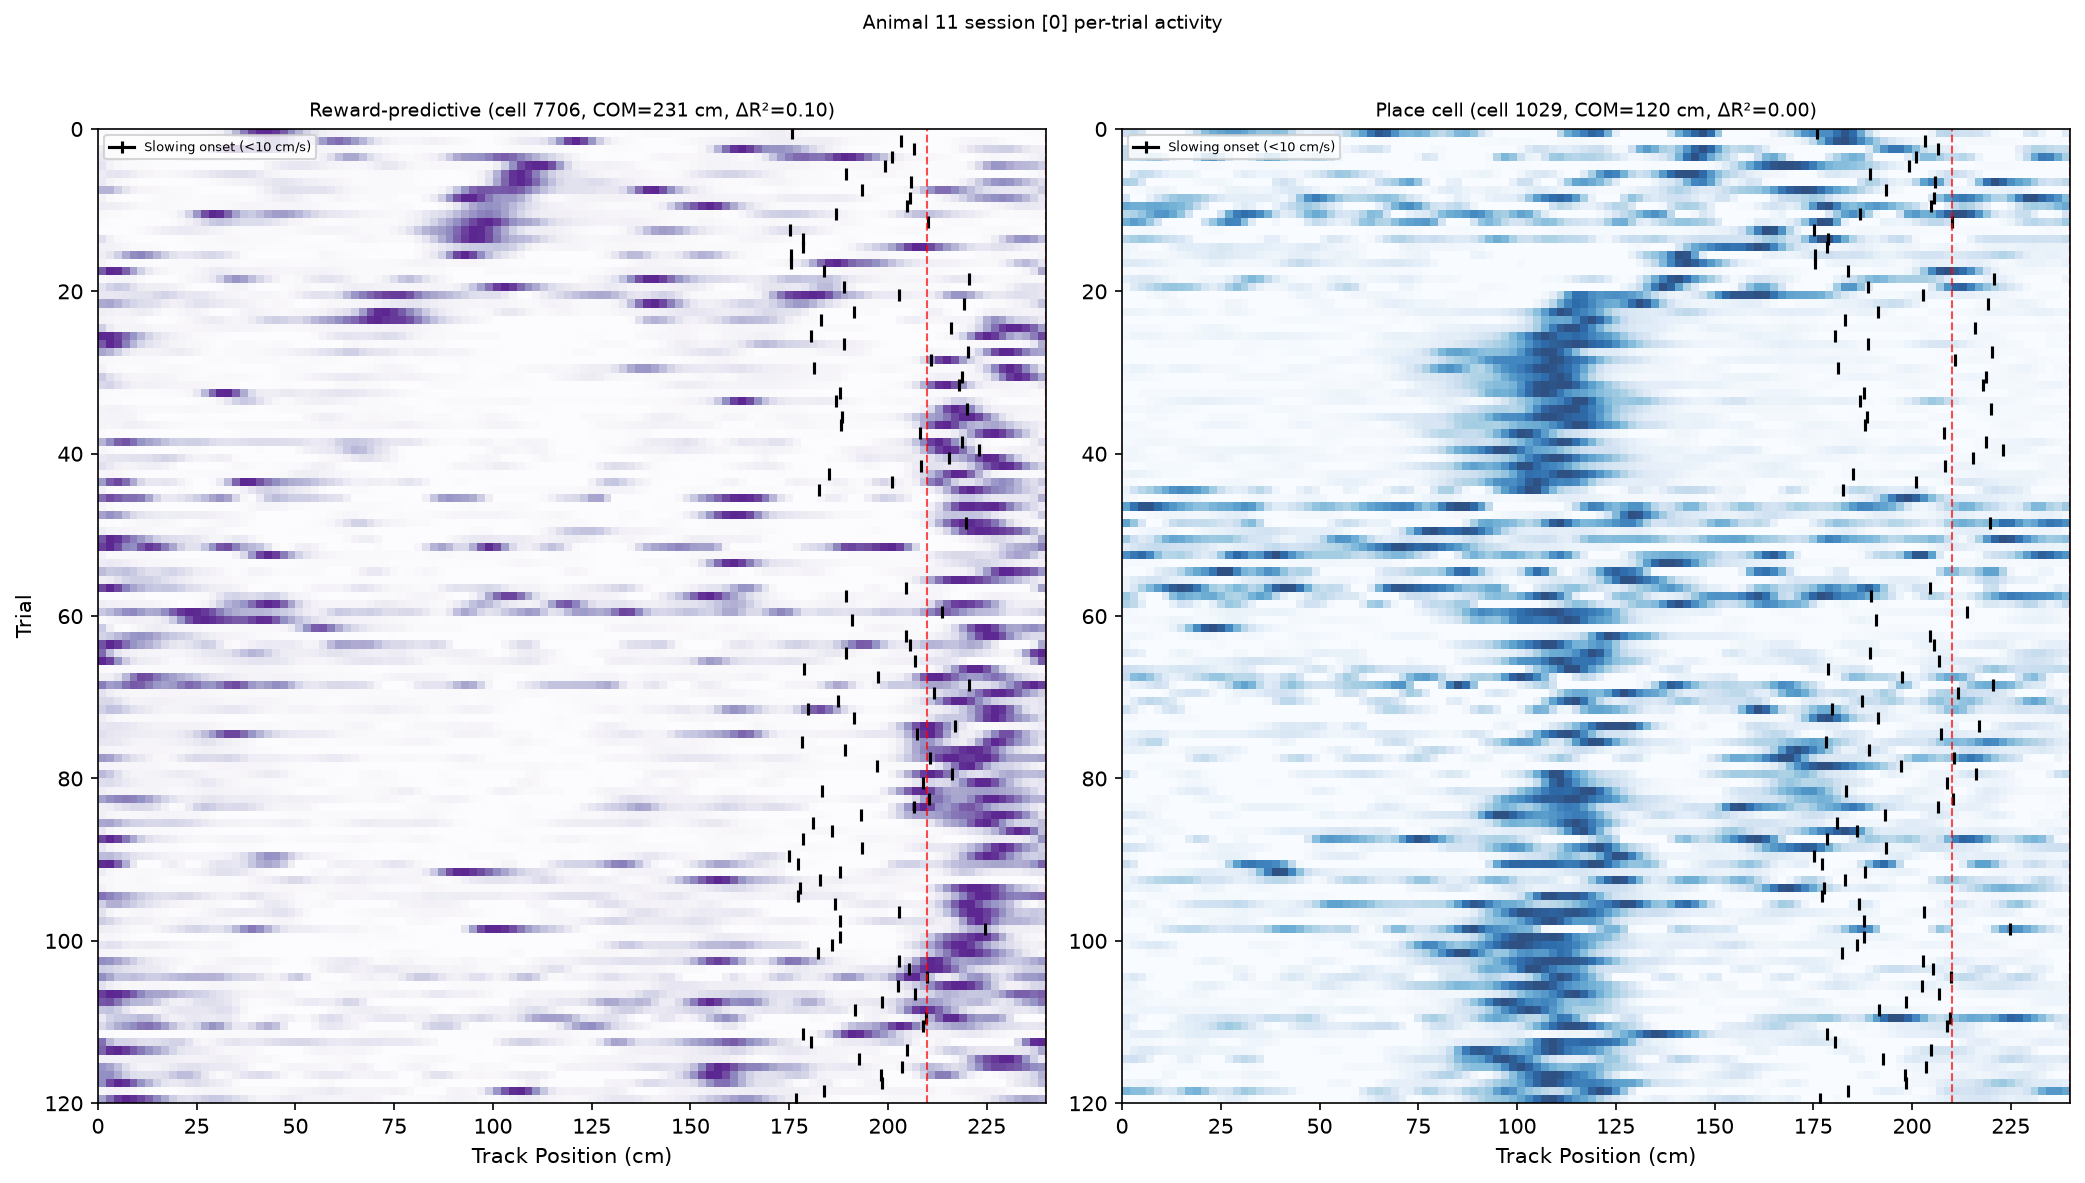

In [51]:
plot_per_trial_activity(
    report=tuning_report,
    trial_type=trial_type,
    session=session,
    title=f"Animal {ANIMAL} session [{SESSION_INDEX}] per-trial activity",
)
plt.show()

### 4.8 Per-day-sorted rate maps across the animal

Per-session view across the animal's full session list: each panel re-sorts cells by *that session's* peak position, so the figure shows the population's day-level tuning band without any across-session correspondence. The classifier defaults to `IS_PLACE` (per-session within-session classification); switch to `"strict_place"` or `"reward"` if you want a tighter or different population.

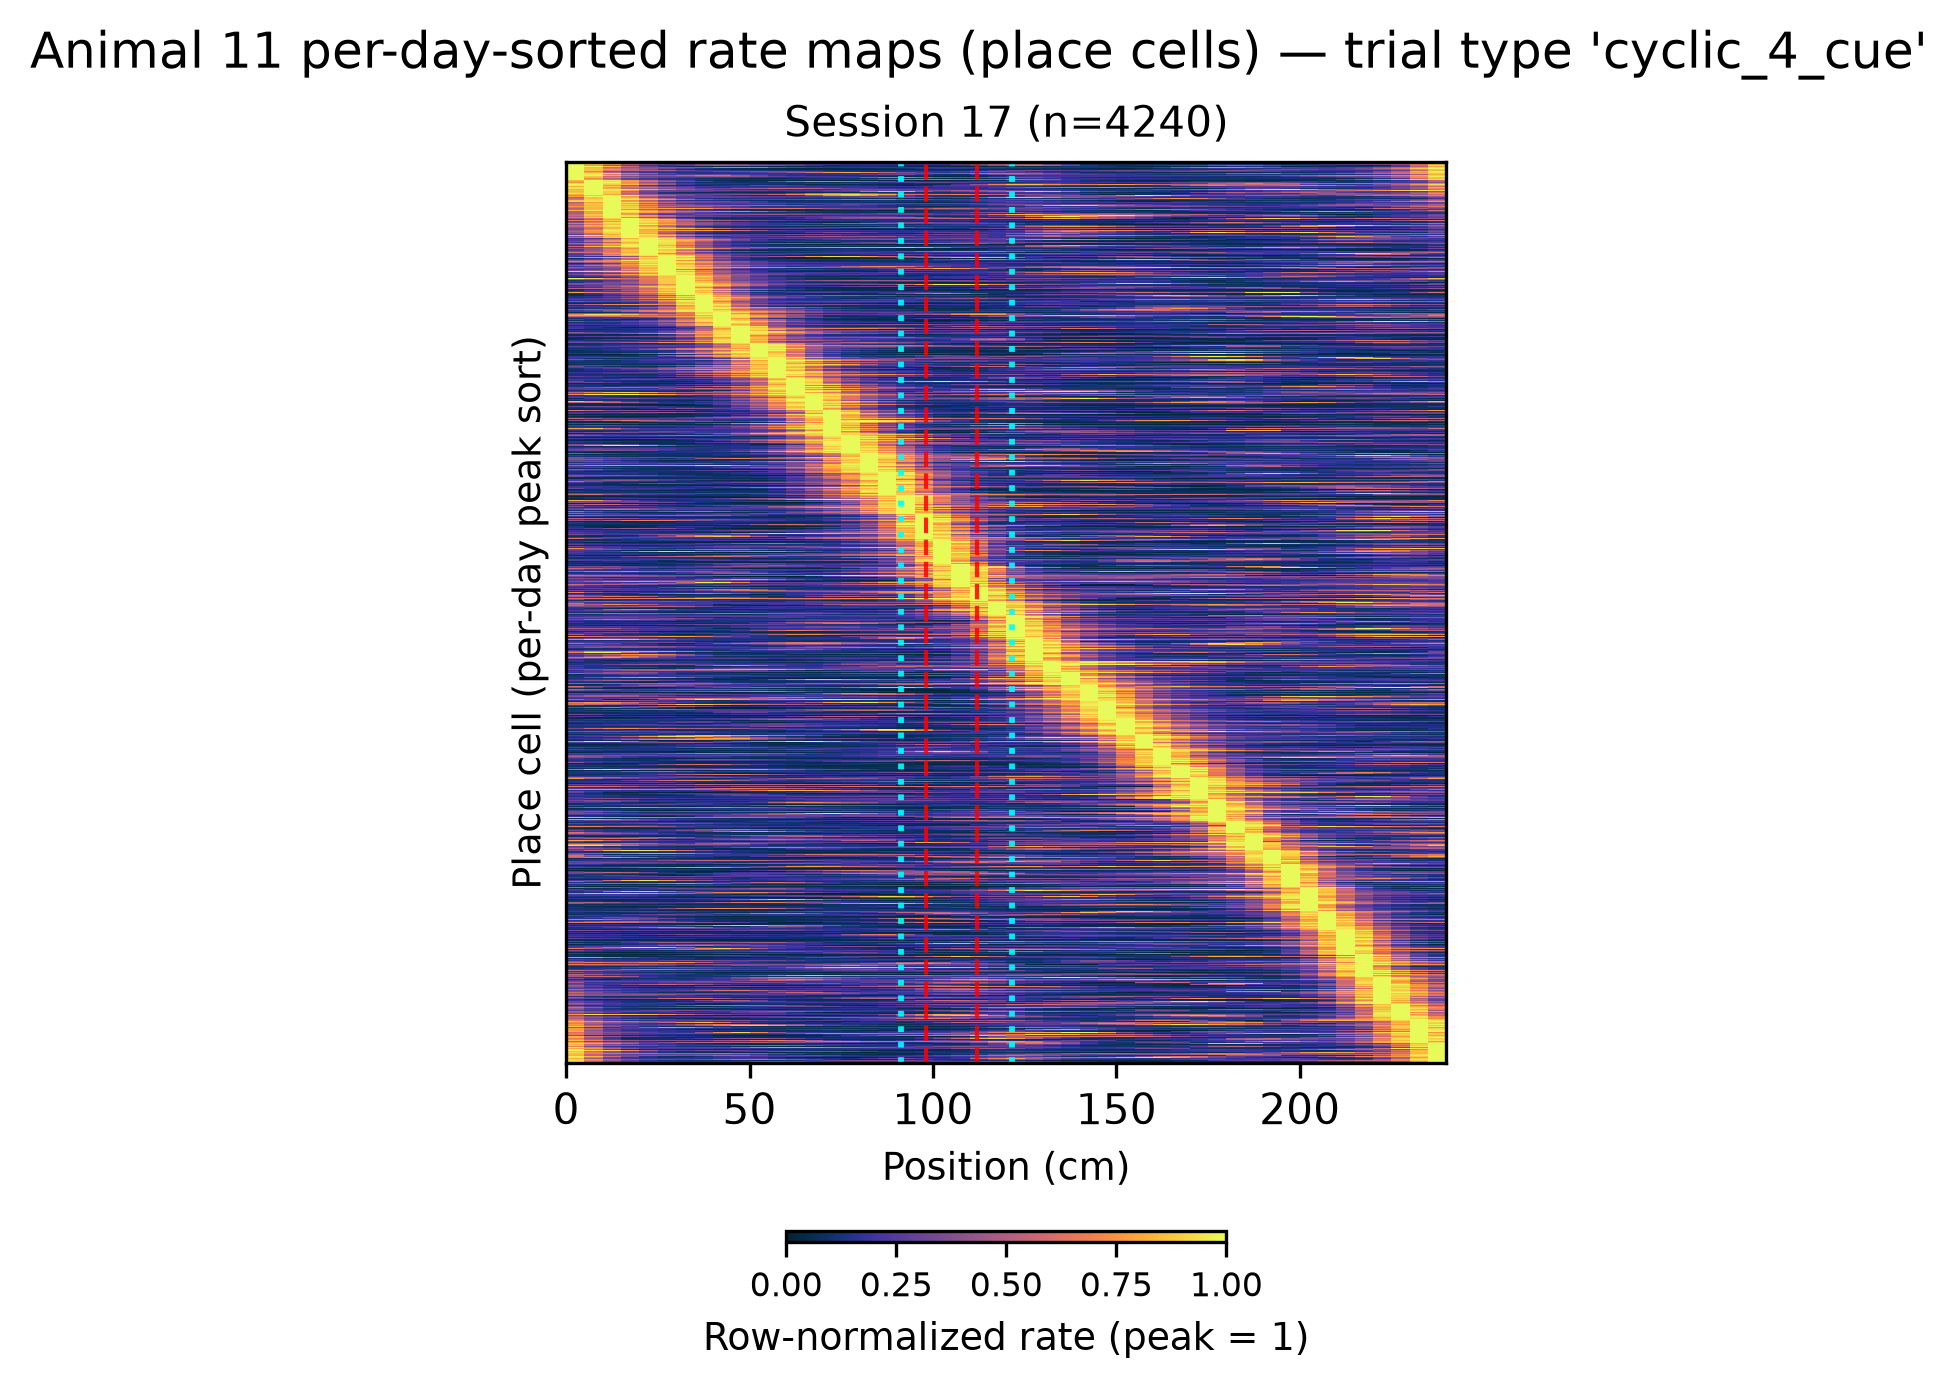

In [31]:
plot_per_day_sorted_rate_maps(
    sessions=sessions,
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=(17,),
    figure_dpi=300,
    cmap="cmo.thermal"
)
plt.show()